Navpreet Kloy, Priyanshu Rathor

Dataset URL: https://www.kaggle.com/datasets/anthonytherrien/depression-dataset

In [ ]:
# call the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving depression_data.csv to depression_data (3).csv


In [ ]:
# reads and stores csv file
df=pd.read_csv('depression_data.csv')
df.head() #displays first five rows

,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,Christine Barker,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes
1,Jacqueline Lewis,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes
2,Shannon Church,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No
3,Charles Jordan,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No
4,Michael Rich,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes


In [ ]:
print(df.isnull().sum())  # Counts the number of missing (NaN) values in each column
print(df.shape) #(rows, columns)


Name                            0
Age                             0
Marital Status                  0
Education Level                 0
Number of Children              0
Smoking Status                  0
Physical Activity Level         0
Employment Status               0
Income                          0
Alcohol Consumption             0
Dietary Habits                  0
Sleep Patterns                  0
History of Mental Illness       0
History of Substance Abuse      0
Family History of Depression    0
Chronic Medical Conditions      0
dtype: int64
(413768, 16)


In [ ]:
print(df.columns.tolist()) #displays all column names

['Name', 'Age', 'Marital Status', 'Education Level', 'Number of Children', 'Smoking Status', 'Physical Activity Level', 'Employment Status', 'Income', 'Alcohol Consumption', 'Dietary Habits', 'Sleep Patterns', 'History of Mental Illness', 'History of Substance Abuse', 'Family History of Depression', 'Chronic Medical Conditions']


In [ ]:
# remove name column
if "Name" in df.columns:
  df = df.drop(columns=["Name"])

In [ ]:
df.head()

,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes
1,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes
2,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No
3,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No
4,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes


In [ ]:
# select binary (Yes/No) columns to convert into numeric (1/0)
binary_cols = [
    "History of Mental Illness",
    "History of Substance Abuse",
    "Family History of Depression",
    "Chronic Medical Conditions"
]


In [ ]:
# convert binary yes/no into 0/1
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].str.strip().map({"Yes": 1, "No": 0})


In [ ]:
df.head()

,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,1,0,1,1
1,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,1,0,0,1
2,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,0,0,1,0
3,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,0,0,0,0
4,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,1,0,1,1


In [ ]:
# define the mapping for categorical variables
ordinal_mappings = {
    "Alcohol Consumption": {"Low": 0, "Moderate": 1, "High": 2},
    "Physical Activity Level": {"Sedentary": 0, "Moderate": 1, "Active": 2},
    "Dietary Habits": {"Unhealthy": 0, "Moderate": 1, "Healthy": 2},
    "Sleep Patterns": {"Poor": 0, "Fair": 1, "Good": 2},
    "Education Level": {"High School":0, "Associate Degree":1, "Bachelor's Degree":2, "Master's Degree":3,"PhD":4}
}


In [ ]:
# apply ordinal mapping to categorical variables
for col, mapping in ordinal_mappings.items():
    if col in df.columns:
        cleaned = df[col].astype(str).str.strip()
        df[col] = cleaned.map(mapping)
        df[col] = df[col].fillna(1).astype(int)

In [ ]:
df.head()

,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,31,Married,2,2,Non-smoker,2,Unemployed,26265.67,1,1,1,1,0,1,1
1,55,Married,0,1,Non-smoker,0,Employed,42710.36,2,0,1,1,0,0,1
2,78,Widowed,3,1,Non-smoker,0,Employed,125332.79,0,0,2,0,0,1,0
3,58,Divorced,3,3,Non-smoker,1,Unemployed,9992.78,1,1,0,0,0,0,0
4,18,Single,0,0,Non-smoker,0,Unemployed,8595.08,0,1,1,1,0,1,1


In [ ]:
# convert remaining catgorical variables using one-hot encode
df = pd.get_dummies(df, drop_first=True)

print("\nAfter encoding shape:", df.shape)



After encoding shape: (413768, 18)


In [ ]:
df.head()

,Age,Education Level,Number of Children,Physical Activity Level,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions,Marital Status_Married,Marital Status_Single,Marital Status_Widowed,Smoking Status_Former,Smoking Status_Non-smoker,Employment Status_Unemployed
0,31,2,2,2,26265.67,1,1,1,1,0,1,1,True,False,False,False,True,True
1,55,0,1,0,42710.36,2,0,1,1,0,0,1,True,False,False,False,True,False
2,78,3,1,0,125332.79,0,0,2,0,0,1,0,False,False,True,False,True,False
3,58,3,3,1,9992.78,1,1,0,0,0,0,0,False,False,False,False,True,True
4,18,0,0,0,8595.08,0,1,1,1,0,1,1,False,True,False,False,True,True


In [ ]:
# create a list of features to use PCA analysis
features = [col for col in df.columns]
print('Number of features:', len(features))
features

Number of features: 18


['Age',
 'Education Level',
 'Number of Children',
 'Physical Activity Level',
 'Income',
 'Alcohol Consumption',
 'Dietary Habits',
 'Sleep Patterns',
 'History of Mental Illness',
 'History of Substance Abuse',
 'Family History of Depression',
 'Chronic Medical Conditions',
 'Marital Status_Married',
 'Marital Status_Single',
 'Marital Status_Widowed',
 'Smoking Status_Former',
 'Smoking Status_Non-smoker',
 'Employment Status_Unemployed']

In [ ]:
df[features].nunique() #check number of unique values in each feature

,0
Age,63
Education Level,5
Number of Children,5
Physical Activity Level,3
Income,405282
Alcohol Consumption,3
Dietary Habits,3
Sleep Patterns,3
History of Mental Illness,2
History of Substance Abuse,2


In [ ]:
#Use StandardScaler to normalize the data
raw_features = df[features]
x = StandardScaler().fit_transform(raw_features)
# Verify normalization worked correctly - Mean should be close to 0, Std should be exactly 1.0
print('Normalized data stats:')
print('  Mean : {:.6f}  (should be ~0)'.format(np.mean(x)))
print('  Std  : {:.6f}  (should be ~1)'.format(np.std(x)))

Normalized data stats:
  Mean : 0.000000  (should be ~0)
  Std  : 1.000000  (should be ~1)


In [ ]:
# Apply PCA to reduce the 18 deminsions to two principal components
pca = PCA(n_components=2)
principal_components = pca.fit_transform(x)
pca_df = pd.DataFrame(principal_components, columns=['PC1', 'PC2'])
print(pca_df.head())

        PC1       PC2
0 -0.272268 -0.595651
1 -0.736170 -0.753570
2 -1.023424  0.870950
3 -1.283278 -0.478221
4  1.999998 -2.889887


In [ ]:
#Caculate explained variance ratio to determine the proportion of information captured
pc1_var, pc2_var = pca.explained_variance_ratio_

print('Explained variance per principal component:')
print('  PC1 : {:.1%}  — direction of greatest spread in the data'.format(pc1_var))
print('  PC2 : {:.1%}  — direction of second greatest spread'.format(pc2_var))
print('  ──────────────────────────────────────────────')
print('  Total: {:.1%}  of original information retained in 2D'.format(pc1_var + pc2_var))

Explained variance per principal component:
  PC1 : 14.5%  — direction of greatest spread in the data
  PC2 : 11.3%  — direction of second greatest spread
  ──────────────────────────────────────────────
  Total: 25.8%  of original information retained in 2D


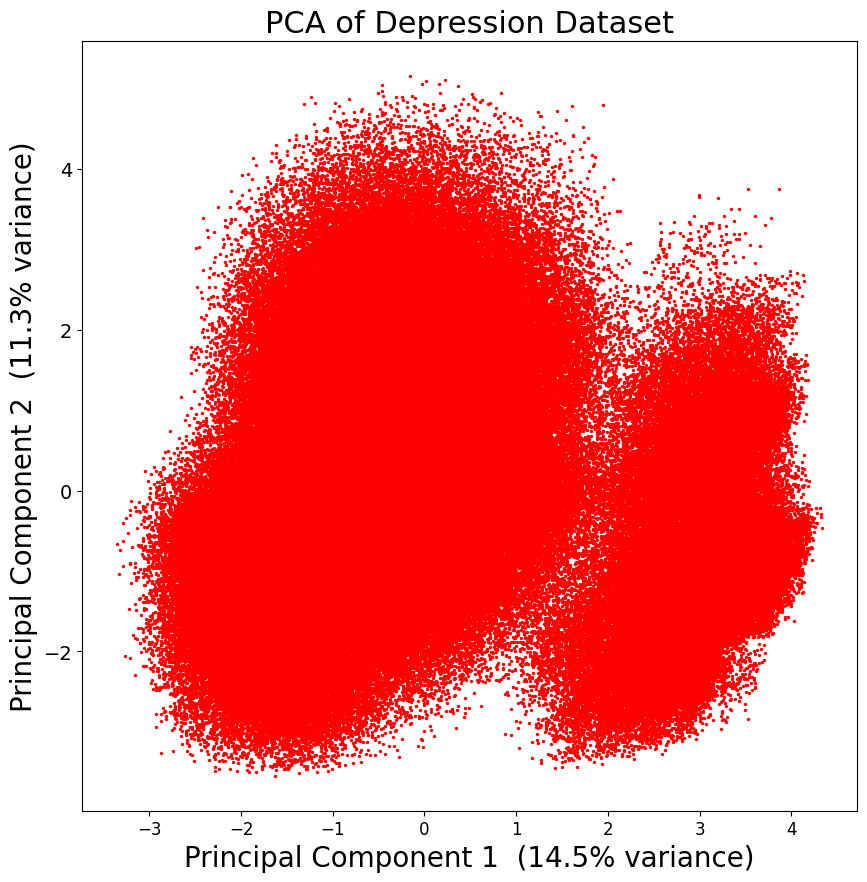

In [ ]:
# Plot the two principles components into a scatterplot
plt.figure(figsize=(10, 10))

# Axis labels and title
plt.xlabel('Principal Component 1  ({:.1%} variance)'.format(pc1_var), fontsize=20)
plt.ylabel('Principal Component 2  ({:.1%} variance)'.format(pc2_var), fontsize=20)
plt.title('PCA of Depression Dataset', fontsize=22)
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)
plt.scatter(pca_df['PC1'],pca_df['PC2'], c='red', s=2)

The Principal Component Analysis (PCA) algorithm was used to transform 18 standardized variables from the Depression dataset into two principal component variables. The depression dataset consisted of a total of 413,768 datapoints, each representing an individual with various health and lifestyle identifiers. The first principle component, representing the greatest variation, explains 14.5% of variability. The second principal component captured 11.3% of the total variability. Together, the total variation of the two principal components explain  25.8% of the total variance data. Additionally, the PCA scatterplot for the two principal components shows two defined groups that suggest individuals with similar health and lifestyle patterns tend to group together.
